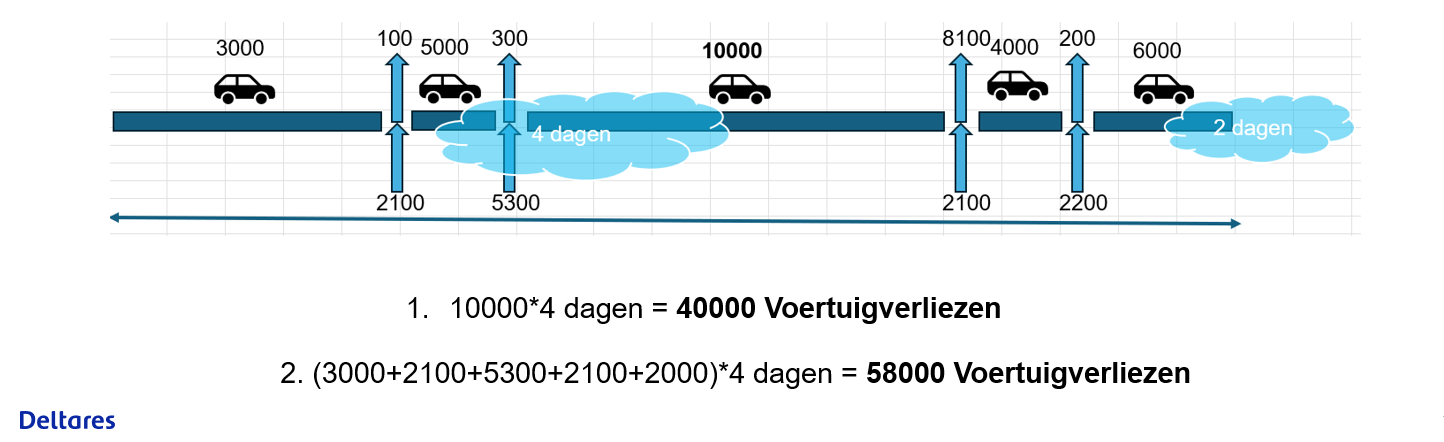

In [2]:
from pathlib import Path
import geopandas as gpd

In [3]:
region_list = ["ARK-NZK","Vallei en Veluwe",
               "Achterhoek", "Brabantse Delta","Friesland",
               "Groningen en NO-Drenthe","Limburg",
               "Noord-Brabant Oost","Noord-Westelijke Delta",
               "Rivierenland","Scheldestromen","Zuiderzeeland",
               "Overijsselse Vecht"
               ]

In [11]:
#Linking traffic data road segments
import pandas as pd
root_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Traffic_Analysis_Data")
root_dir.mkdir(parents=True, exist_ok=True)
data = Path(r"P:\bovenregionale-stresstest-hwn\Data\Traffic_data\INWEVA_2024 (1)")
traffic_geometry_path=data.joinpath("INWEVA_2024_netwerk\INWEVA_2024_netwerk.shp") 
werkdag_traffic_csv_path = data.joinpath("inweva_werkdag_2024DEC.csv")
traffic_geometry= gpd.read_file(traffic_geometry_path, driver='SHP') 
traffic= pd.read_csv(werkdag_traffic_csv_path, sep=';') 

traffic_subset = traffic[['VBN_ID', 'AL_E_WR', 'VRPC_E_WR','L1_E_WR','L2_E_WR','L3_E_WR']]
traffic_subset['VBN_ID'] = traffic_subset['VBN_ID'].astype(str)
result = traffic_geometry.merge(traffic_subset, left_on='vbn_id', right_on='VBN_ID', how='left')
print(f"Original traffic_geometry rows: {len(traffic_geometry)}")
print(f"Result rows: {len(result)}")
print(result.columns.tolist())

# Save the result as a geopackage
# Rename the VBN_ID column to avoid conflicts
result_renamed = result.rename(columns={'VBN_ID': 'traffic_vbn_id'})

output_path = root_dir.joinpath("traffic_werkdag_2024DEC.gpkg")
if output_path.exists():  # overwrite existing file
    output_path.unlink()
result_renamed.to_file(output_path, driver='GPKG')
print(f"Saved merged data to: {output_path}")
#print(f"Saved merged data to: {output_path}")

result_renamed = result.drop(columns=['VBN_ID'])# Rename the VBN_ID column to avoid conflicts
result_exploded = result_renamed.copy()# Split nwb_ids and create duplicate rows for each value
result_exploded['nwb_ids'] = result_exploded['nwb_ids'].str.split(', ')# Split the nwb_ids column by comma and expand into separate rows
result_exploded = result_exploded.explode('nwb_ids')
result_exploded = result_exploded.reset_index(drop=True)# Reset index after exploding
result_exploded['individual_nwb_id'] = result_exploded['nwb_ids']# Create a new column with individual nwb_id values
#print(f"Original rows: {len(result_renamed)}")
#print(f"Exploded rows: {len(result_exploded)}")

### check here!!!
# Select only the required columns from traffic and create a proper copy
#AL_D_WR = Totale INWEVA intensiteit over periode 'dag' (7:00 - 19:00 uur) alle voertuigen werkdag (in mvt)
#VRPC_D_WR = Vrachtpercentage dag werkdag, Freight percentage day working day
traffic_subset_ver01 = result_exploded[['individual_nwb_id', 'L1_E_WR','L2_E_WR','L3_E_WR', 'AL_E_WR', 'VRPC_E_WR','vbn_oms_tx','bnsubsrt_b','bnsubsrt_e','nwb_ids']].copy() 
# Convert both columns to string to ensure they match
traffic_subset_ver01['individual_nwb_id'] = traffic_subset_ver01['individual_nwb_id'].astype(str)

C:\Users\gunaratn\AppData\Local\Temp\ipykernel_492\3582970436.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  traffic_subset['VBN_ID'] = traffic_subset['VBN_ID'].astype(str)


Original traffic_geometry rows: 9049
Result rows: 9049
['vbn_id', 'vbn_oms_tx', 'vbn_oms_bp', 'vbn_lengte', 'regio_cntr', 'regio_alt', 'nwb_ids', 'wegnrhmp_b', 'wegnrhmp_e', 'bpszijde_b', 'bpszijde_e', 'hectoltr_b', 'hectoltr_e', 'bnsubsrt_b', 'bnsubsrt_e', 'km_b', 'km_e', 'hm_midden', 'vbn_id_tgn', 'vias_baan', 'geometry', 'VBN_ID', 'AL_E_WR', 'VRPC_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR']
Saved merged data to: P:\bovenregionale-stresstest-hwn\Analysis\Traffic_Analysis_Data\traffic_werkdag_2024DEC.gpkg


In [14]:
# this cell combines all traffic data from different regions

import pandas as pd
import geopandas as gpd
from pathlib import Path

region_list = [
    "ARK-NZK","Vallei en Veluwe","Achterhoek", "Brabantse Delta","Friesland",
    "Groningen en NO-Drenthe","Limburg","Noord-Brabant Oost","Noord-Westelijke Delta",
    "Rivierenland","Scheldestromen","Zuiderzeeland","Overijsselse Vecht"
]

all_roads = []

for region in region_list:
    root_dir = Path(rf"P:\bovenregionale-stresstest-hwn\Analysis\{region}\Outputs")
    road_path = root_dir / "Damages_Filtering_all_columns.gpkg"
    if not road_path.exists():
        print(f"File not found for region {region}: {road_path}. Skipping.")
        continue
    road = gpd.read_file(road_path, driver='GPKG')
    road['region'] = region  # Optionally keep track of region
    all_roads.append(road)

if not all_roads:
    print("No region data found.")
else:
    # Combine all regions into one GeoDataFrame
    combined_roads = gpd.GeoDataFrame(pd.concat(all_roads, ignore_index=True), crs=all_roads[0].crs)

    # Do NOT drop duplicates. Instead, aggregate by WVK_ID and geometry, keeping the row with highest F_EV1_me. - if there are overlapping segments but flooding from another region 
    # If multiple rows have F_EV1_me == 0, keep the first one. -> because there are overlapping segments with different F_EV1_me values.
   
    # Combine all regions into one GeoDataFrame
    combined_roads = gpd.GeoDataFrame(pd.concat(all_roads, ignore_index=True), crs=all_roads[0].crs)

    # Do NOT drop duplicates. Instead, aggregate by WVK_ID and geometry, keeping the row with highest F_EV1_me.
    # If multiple rows have F_EV1_me == 0, keep the first one.
    combined_roads['WVK_ID'] = combined_roads['WVK_ID'].astype(str).str.replace('.0', '', regex=False).str.strip()
    combined_roads.sort_values(['WVK_ID', 'geometry', 'F_EV1_me'], ascending=[True, True, False], inplace=True)
    combined_roads = combined_roads.groupby(['WVK_ID', 'geometry'], as_index=False).first()

    # Ensure road_copy is a GeoDataFrame so dissolve works
    road_copy = gpd.GeoDataFrame(combined_roads.copy(), geometry='geometry', crs="EPSG:28992")

    fev1_cols = [c for c in road_copy.columns if c.startswith('F_EV1')]
    fev2_cols = [c for c in road_copy.columns if c.startswith('F_EV2')]


    # this is artefact filtering
    if 'remove' in road_copy.columns and (road_copy['remove'] == 1).any():
        mask_remove = road_copy['remove'] == 1
        if fev1_cols:
            road_copy.loc[mask_remove, fev1_cols] = 0
        if fev2_cols:
            road_copy.loc[mask_remove, fev2_cols] = 0
        print(f"Set F_EV1* and F_EV2* to 0 for {mask_remove.sum()} rows where remove == 1")

    if 'F_EV1_me' in road_copy.columns and fev2_cols:
        mask_low = road_copy['F_EV1_me'] < 0.1
        if mask_low.any():
            road_copy.loc[mask_low, fev2_cols] = 0
            print(f"Set F_EV2* to 0 for {mask_low.sum()} rows where F_EV1_me < 0.1")

    # Because we need to do complex losses for networkschakels that has more than one flooded segments
    # Count number of flooded segments per NETWERKSCH_HWN
    mask = (road_copy['F_EV1_me'] > 0) & (road_copy['F_EV2_ma'] > 0)
    flooded_counts = (
        road_copy[mask]
        .groupby('NETWERKSCH_HWN')
        .size()
        .rename('No_seg_flooded')
    )
    road_copy['No_seg_flooded'] = road_copy['NETWERKSCH_HWN'].map(flooded_counts).fillna(0).astype(int)


    agg_dict = {}
    for col in road_copy.columns:
        if col in ['geometry', 'WVK_ID']:
            continue
        if col in ['F_EV2_ma', 'F_EV1_me', 'F_EV1_ma']:
            agg_dict[col] = 'max'
        elif road_copy[col].dtype.kind in 'biufc':
            agg_dict[col] = 'max'
        else:
            agg_dict[col] = 'first'

    

    if agg_dict:
        road_agg = road_copy.dissolve(by='WVK_ID', aggfunc=agg_dict).reset_index()
    else:
        road_agg = road_copy.drop_duplicates(subset=['WVK_ID']).reset_index(drop=True)

    road_agg['WVK_ID'] = road_agg['WVK_ID'].astype(str).str.replace('.0', '', regex=False).str.strip()

    # JOIN with traffic (traffic_subset_ver01 must exist and have individual_nwb_id as str)
    merged = road_agg.merge(traffic_subset_ver01, left_on='WVK_ID', right_on='individual_nwb_id', how='left',suffixes=('', '_traffic'))
    #'AL_E_WR', 'VRPC_E_WR'
    if 'AL_E_WR' in merged.columns:
        merged['AL_E_WR'] = pd.to_numeric(merged['AL_E_WR'], errors='coerce').fillna(0)
    else:
        merged['AL_E_WR'] = 0
    if 'VRPC_E_WR' in merged.columns:
        merged['VRPC_E_WR'] = pd.to_numeric(merged['VRPC_E_WR'], errors='coerce').fillna(0)
    else:
        merged['VRPC_E_WR'] = 0
    if 'F_EV2_ma' not in merged.columns:
        merged['F_EV2_ma'] = 0

    merged['traffic_AL_E_WR'] = merged['AL_E_WR'] * merged['F_EV2_ma']
    merged['traffic_L1_E_WR'] = merged['L1_E_WR'] * merged['F_EV2_ma']
    merged['traffic_L2_E_WR'] = merged['L2_E_WR'] * merged['F_EV2_ma']
    merged['traffic_L3_E_WR'] = merged['L3_E_WR'] * merged['F_EV2_ma']
    merged['traffic_VRPC_E_WR'] = merged['VRPC_E_WR'] * merged['F_EV2_ma'] # does this make sense?

    columns_to_keep = [
    'WVK_ID','geometry','BST_CODE_NWB' , 'No_seg_flooded','F_EV1_me', 'F_EV2_ma', 'AL_E_WR','L1_E_WR','L2_E_WR','L3_E_WR','VRPC_E_WR','traffic_L1_E_WR','traffic_L2_E_WR','traffic_L3_E_WR',
    'traffic_AL_E_WR', 'traffic_VRPC_E_WR','vbn_oms_tx','bnsubsrt_b','bnsubsrt_e','nwb_ids','HECTO_LTTR_NWB','NETWERKSCH_HWN'
    ]
    # Only keep columns that exist in merged
    columns_to_keep = [col for col in columns_to_keep if col in merged.columns]
    merged = merged[columns_to_keep]

    # Save result
    output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
    out_path = output_dir.joinpath("Traffic_Analysis_Country_ver03.gpkg")
    if out_path.exists():
        out_path.unlink()
    merged.to_file(out_path, driver='GPKG')
    print(f"Saved combined country-scale road and traffic data to: {out_path}")

    

File not found for region Brabantse Delta: P:\bovenregionale-stresstest-hwn\Analysis\Brabantse Delta\Outputs\Damages_Filtering_all_columns.gpkg. Skipping.
Set F_EV1* and F_EV2* to 0 for 81512 rows where remove == 1
Set F_EV2* to 0 for 81512 rows where F_EV1_me < 0.1
Saved combined country-scale road and traffic data to: P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Traffic_Analysis_Country_ver03.gpkg


In [13]:
print(merged.columns.tolist())

['WVK_ID', 'geometry', 'BST_CODE_NWB', 'F_EV1_me', 'F_EV2_ma', 'AL_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR', 'VRPC_E_WR', 'traffic_L1_E_WR', 'traffic_L2_E_WR', 'traffic_L3_E_WR', 'traffic_AL_E_WR', 'traffic_VRPC_E_WR', 'vbn_oms_tx', 'bnsubsrt_b', 'bnsubsrt_e', 'nwb_ids', 'HECTO_LTTR_NWB', 'NETWERKSCH_HWN']


In [ ]:
#Code for simple losses


# Steps performed in this cell:
# 1. Load country-level traffic GeoPackage into HWN_traffic.
# 2. Aggregate values per NETWERKSCH_HWN: collect traffic_AL_D_WR and F_EV2_ma into lists via dissolve.
# 3. (Important) When computing maxima, do not consider values from rows where HECTO_LTTR_NWB is one of a, b, c, d.
# 4. Compute s_traffic_AL_D_WR as the max of the traffic list (after excluding the letters above).
# 5. Compute max_F_EV2_ma as the max of the F_EV2_ma list (after excluding the letters above).
# 6. Rename list columns for clarity and convert list columns to comma-separated strings for saving.
# 7. Compute simple_losses = s_traffic_AL_D_WR * max_F_EV2_ma and save the result to a geopackage.
#
# Note: Current code below creates lists and computes maxima; to enforce step 3 you need to filter HECTO_LTTR_NWB
#       before aggregating or create filtered list columns and take max from those filtered lists.



# Losses for schakel
HWN_traffic_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Traffic_Analysis_Country_ver02.gpkg")
HWN_traffic = gpd.read_file(HWN_traffic_path, driver='GPKG')

# Normalize HECTO_LTTR_NWB and create mask for excluded letters a,b,c,d (case-insensitive)
HWN_traffic['HECTO_LTTR_NWB'] = HWN_traffic.get('HECTO_LTTR_NWB', '').astype(str).str.lower().str.strip()
exclude_letters = {'a', 'b', 'c', 'd'}
mask_exclude = HWN_traffic['HECTO_LTTR_NWB'].isin(exclude_letters)

# Create filtered columns that are None for excluded HECTO_LTTR_NWB rows
HWN_traffic['traffic_AL_E_WR_filtered'] = HWN_traffic['traffic_AL_E_WR'].where(~mask_exclude, None)
HWN_traffic['F_EV2_ma_filtered'] = HWN_traffic.get('F_EV2_ma', 0).where(~mask_exclude, None)

# Dissolve HWN_traffic by NETWERKSCH_HWN, aggregate traffic/F_EV2 as lists (both original and filtered)
dissolved = HWN_traffic.dissolve(
    by='NETWERKSCH_HWN',
    aggfunc={
        'traffic_AL_E_WR': list,              # all values
        'F_EV2_ma': list,                     # all values
        'traffic_AL_E_WR_filtered': list,     # filtered (excludes rows with HECTO_LTTR_NWB in a,b,c,d)
        'F_EV2_ma_filtered': list             # filtered
    }
).reset_index()

# Utility to get max while ignoring None/NaN
def max_ignore_none(lst):
    if not isinstance(lst, list):
        return None
    clean = [i for i in lst if pd.notnull(i)]
    return max(clean) if clean else None

# Add s_traffic_AL_E_WR using the filtered list (so excluded letters are ignored)
dissolved['s_traffic_AL_E_WR'] = dissolved['traffic_AL_E_WR_filtered'].apply(max_ignore_none)

# Add max_F_EV2_ma using the filtered list
dissolved['max_F_EV2_ma'] = dissolved['F_EV2_ma_filtered'].apply(max_ignore_none)

# Optionally rename list columns for clarity (keep both original-list and filtered-list names)
dissolved.rename(columns={
    'traffic_AL_E_WR': 'traffic_AL_E_WR_list',
    'F_EV2_ma': 'F_EV2_ma_list',
    'traffic_AL_E_WR_filtered': 'traffic_AL_E_WR_filtered_list',
    'F_EV2_ma_filtered': 'F_EV2_ma_filtered_list'
}, inplace=True)

# Convert lists to comma-separated strings before saving (for all list columns)
for col in ['traffic_AL_E_WR_list', 'F_EV2_ma_list', 'traffic_AL_E_WR_filtered_list', 'F_EV2_ma_filtered_list']:
    if col in dissolved.columns:
        dissolved[col] = dissolved[col].apply(lambda x: ",".join([str(i) for i in x]) if isinstance(x, list) else "")

# Compute simple losses (will be NaN if either is None; change to 0 if you prefer)
dissolved['simple_losses'] = dissolved['s_traffic_AL_E_WR'] * dissolved['max_F_EV2_ma']

output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
out_path = output_dir.joinpath("Simple_Losses_Analysis_Schakel_level.gpkg")
dissolved.to_file(out_path, driver="GPKG")


In [ ]:
#Code for complex lossess - Part 01 : getting the first asegments of each schakel

traffic_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Traffic_Analysis_Country_ver03.gpkg")
traffic = gpd.read_file(traffic_path, driver='GPKG')

NWB_network = Path(r"P:\bovenregionale-stresstest-hwn\Data\Road_data\Rijkswegen_uit_nwb\rijkswegen.shp")
NWB_network_gdf = gpd.read_file(NWB_network, driver='SHP')

traffic['WVK_ID'] = traffic['WVK_ID'].astype(str).str.replace('.0', '', regex=False).str.strip()
NWB_network_gdf['WVK_ID'] = NWB_network_gdf['WVK_ID'].astype(str).str.replace('.0', '', regex=False).str.strip()

#First we need the relevant columns from NWB_network_gdf
traffic['WVK_ID'] = traffic['WVK_ID'].astype(str)
NWB_network_gdf['WVK_ID'] = NWB_network_gdf['WVK_ID'].astype(str)

columns_to_add = ['WVK_ID', 'JTE_ID_BEG', 'JTE_ID_END']  # add more if needed

traffic_with_nwb = traffic.merge(
    NWB_network_gdf[columns_to_add],
    on='WVK_ID',
    how='left'
)

print(traffic_with_nwb.columns)

# Keep only rows where NETWERKSCH_HWN != '000-0000-M' 
net_col = 'NETWERKSCH_HWN' if 'NETWERKSCH_HWN' in traffic_with_nwb.columns else None
if net_col is not None:
    before = len(traffic_with_nwb)
    mask = traffic_with_nwb[net_col].fillna('').astype(str).str.strip().ne('000-0000-M')
    traffic_with_nwb = traffic_with_nwb.loc[mask].copy()
    print(f"Filtered {before - len(traffic_with_nwb)} rows where {net_col} == '000-0000-M'")
else:
    print("Warning: Neither 'NETWERKSCH' nor 'NETWERKSCH_HWN' present; no filtering applied.")


# Tag 'position' per NETWERKSCH_HWN using JTE_ID_BEG/JTE_ID_END on main carriageway ('#')
import pandas as pd
import geopandas as gpd

# Ensure we operate on a GeoDataFrame and keep geometry/CRS
df = gpd.GeoDataFrame(traffic_with_nwb.copy(), geometry='geometry', crs=getattr(traffic_with_nwb, 'crs', None))

required = ['NETWERKSCH_HWN', 'HECTO_LTTR_NWB', 'JTE_ID_BEG', 'JTE_ID_END']
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

def norm_id(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.replace('.0', '', regex=False)
    s = s.where(~s.isin(['', 'nan', 'NaN', 'None']), pd.NA)
    return s

df['JTE_ID_BEG'] = norm_id(df['JTE_ID_BEG'])
df['JTE_ID_END'] = norm_id(df['JTE_ID_END'])

# Default label for all rows
df['position'] = 'middle'  # (spelling as requested)

# Work only on main carriageway rows for the logic
mask_hash = df['HECTO_LTTR_NWB'].astype(str).str.strip() == '#'
groups = df.loc[mask_hash].groupby('NETWERKSCH_HWN').groups

for schakel, idxs in groups.items():
    sub = df.loc[idxs]

    beg_vals = set(sub['JTE_ID_BEG'].dropna().astype(str).unique().tolist())
    end_vals = set(sub['JTE_ID_END'].dropna().astype(str).unique().tolist())

    # List out values per schakel
    print(f"NETWERKSCH_HWN={schakel} | JTE_ID_BEG: {sorted(beg_vals)} | JTE_ID_END: {sorted(end_vals)}")

    # Unique beginnings -> first
    uniq_beg = beg_vals - end_vals
    if uniq_beg:
        mark_idx_first = sub.index[sub['JTE_ID_BEG'].isin(uniq_beg)]
        df.loc[mark_idx_first, 'position'] = 'first'

    # Unique ends -> last
    uniq_end = end_vals - beg_vals
    if uniq_end:
        mark_idx_last = sub.index[sub['JTE_ID_END'].isin(uniq_end)]
        df.loc[mark_idx_last, 'position'] = 'last'

# Keep result as GeoDataFrame
traffic_with_nwb = df
'''
output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
output_dir.mkdir(parents=True, exist_ok=True)
out_path = output_dir / "Check_ends.gpkg"
if out_path.exists():
    out_path.unlink()
traffic_with_nwb.to_file(out_path, driver="GPKG")
print(f"Wrote GeoPackage with positions: {out_path}")
'''


Index(['WVK_ID', 'BST_CODE_NWB', 'No_seg_flooded', 'F_EV1_me', 'F_EV2_ma',
       'AL_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR', 'VRPC_E_WR',
       'traffic_L1_E_WR', 'traffic_L2_E_WR', 'traffic_L3_E_WR',
       'traffic_AL_E_WR', 'traffic_VRPC_E_WR', 'vbn_oms_tx', 'bnsubsrt_b',
       'bnsubsrt_e', 'nwb_ids', 'HECTO_LTTR_NWB', 'NETWERKSCH_HWN', 'geometry',
       'JTE_ID_BEG', 'JTE_ID_END'],
      dtype='object')
Filtered 0 rows where NETWERKSCH_HWN == '000-0000-M'
NETWERKSCH_HWN=001-0010-L | JTE_ID_BEG: ['252370077', '253369192', '254368106', '255366091', '255367061', '256366053', '257365110'] | JTE_ID_END: ['251369010', '252370077', '253369192', '254368106', '255366091', '255367061', '256366053']
NETWERKSCH_HWN=001-0010-R | JTE_ID_BEG: ['251368069', '251369007', '251369013', '253369181', '254368093', '255367062', '256366049', '256366061'] | JTE_ID_END: ['251369007', '251369013', '253369181', '254368093', '255367062', '256366049', '256366061', '257365117']
NETWERKSCH_HWN=001-0020-L | J

'\noutput_dir = Path(r"P:\x08ovenregionale-stresstest-hwn\\Analysis\\Losses_Analysis")\noutput_dir.mkdir(parents=True, exist_ok=True)\nout_path = output_dir / "Check_ends.gpkg"\nif out_path.exists():\n    out_path.unlink()\ntraffic_with_nwb.to_file(out_path, driver="GPKG")\nprint(f"Wrote GeoPackage with positions: {out_path}")\n'

In [ ]:
#Code for complex lossess - Part 02 : dissolving OPR and AFR

import pandas as pd
import geopandas as gpd
from pathlib import Path
from collections import defaultdict

# Ensure GeoDataFrame and CRS
gdf = gpd.GeoDataFrame(traffic_with_nwb.copy(), geometry='geometry', crs=getattr(traffic_with_nwb, 'crs', None))
if gdf.crs is None:
    gdf.set_crs("EPSG:28992", inplace=True)

req = ['NETWERKSCH_HWN', 'BST_CODE_NWB', 'JTE_ID_BEG', 'JTE_ID_END', 'geometry']
missing = [c for c in req if c not in gdf.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

def norm(s: pd.Series) -> pd.Series:
    out = s.astype(str).str.strip().str.replace('.0', '', regex=False)
    return out.where(~out.isin(['', 'nan', 'NaN', 'None']), pd.NA)

def dissolve_by_connectivity(sub: gpd.GeoDataFrame, code: str) -> gpd.GeoDataFrame:
    sub = sub[sub['BST_CODE_NWB'].astype(str).str.strip().eq(code)].copy()
    if sub.empty:
        return sub
    sub['JTE_ID_BEG'] = norm(sub['JTE_ID_BEG'])
    sub['JTE_ID_END'] = norm(sub['JTE_ID_END'])

    # Build connected components (union where JTE_ID_BEG == other JTE_ID_END or vice versa)
    idxs = sub.index.tolist()
    parent = {i: i for i in idxs}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    beg_map, end_map = defaultdict(list), defaultdict(list)
    for i, v in sub['JTE_ID_BEG'].items():
        if pd.notna(v):
            beg_map[str(v)].append(i)
    for i, v in sub['JTE_ID_END'].items():
        if pd.notna(v):
            end_map[str(v)].append(i)

    for val in set(beg_map) & set(end_map):
        nodes = beg_map[val] + end_map[val]
        if len(nodes) > 1:
            anchor = nodes[0]
            for node in nodes[1:]:
                union(anchor, node)

    roots = {i: find(i) for i in idxs}
    root_to_seq, seq = {}, 0
    comp_labels = {}
    for i, r in roots.items():
        if r not in root_to_seq:
            seq += 1
            root_to_seq[r] = seq
        comp_labels[i] = root_to_seq[r]
    sub = sub.join(pd.Series(comp_labels, name='component_seq'))

    sub['component_id'] = sub['NETWERKSCH_HWN'].astype(str) + "_c" + sub['component_seq'].astype('Int64').astype(str)

    max_cols = [
        'F_EV1_me', 'F_EV2_ma', 'AL_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR',
        'VRPC_E_WR', 'traffic_L1_E_WR', 'traffic_L2_E_WR', 'traffic_L3_E_WR',
        'traffic_AL_E_WR', 'traffic_VRPC_E_WR'
    ]
    max_cols = [c for c in max_cols if c in sub.columns]
    for c in max_cols:
        sub[c] = pd.to_numeric(sub[c], errors='coerce')

    def join_uniq(series: pd.Series) -> str:
        vals = [str(v) for v in series.dropna().astype(str) if str(v).strip() != ""]
        return ",".join(sorted(set(vals)))

    # Build agg dict — skip grouping keys to avoid duplicate columns on reset_index
    agg_dict = {}
    skip = {'geometry', 'component_seq', 'NETWERKSCH_HWN', 'component_id'}
    for c in sub.columns:
        if c in skip:
            continue
        if c in max_cols:
            agg_dict[c] = 'max'
        else:
            agg_dict[c] = join_uniq

    dissolved = sub.dissolve(by=['NETWERKSCH_HWN', 'component_id'], aggfunc=agg_dict).reset_index()
    return gpd.GeoDataFrame(dissolved, geometry='geometry', crs=sub.crs or gdf.crs)


opr_dissolved = dissolve_by_connectivity(gdf, 'OPR')
afr_dissolved = dissolve_by_connectivity(gdf, 'AFR')  # use gdf, not opr_dissolved

merged_components = gpd.GeoDataFrame(
    pd.concat([opr_dissolved, afr_dissolved], ignore_index=True),
    geometry='geometry',
    crs=opr_dissolved.crs
)
'''
print(f"Merged rows: {len(merged_components)}")

# Optional: save
out_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "OPR_AFR_components.gpkg"
if out_path.exists():
    out_path.unlink()
merged_components.to_file(out_path, driver="GPKG")
print(f"Wrote: {out_path}")

'''

'\nprint(f"Merged rows: {len(merged_components)}")\n\n# Optional: save\nout_dir = Path(r"P:\x08ovenregionale-stresstest-hwn\\Analysis\\Losses_Analysis")\nout_dir.mkdir(parents=True, exist_ok=True)\nout_path = out_dir / "OPR_AFR_components.gpkg"\nif out_path.exists():\n    out_path.unlink()\nmerged_components.to_file(out_path, driver="GPKG")\nprint(f"Wrote: {out_path}")\n\n'

In [ ]:
#Code for complex lossess - Part 03 : creating the final combined file

# add dissolved oprit afrit to the main traffic_with_nwb file
filtered = traffic_with_nwb[
    ~traffic_with_nwb['BST_CODE_NWB'].astype(str).str.strip().isin(['OPR', 'AFR'])
].copy()


# Concatenate merged_components and filtered (stack rows, keep all columns)
import geopandas as gpd
import pandas as pd

# Ensure both are GeoDataFrames and have the same CRS
if merged_components.crs != filtered.crs:
    filtered = filtered.to_crs(merged_components.crs)

combined_all = gpd.GeoDataFrame(
    pd.concat([filtered, merged_components], ignore_index=True),
    geometry='geometry',
    crs=merged_components.crs
)

out_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "Network_for_complex_losses.gpkg"
if out_path.exists():
    out_path.unlink()
combined_all.to_file(out_path, driver="GPKG")
print(f"Wrote: {out_path}")

CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET last_change = strftime('%Y-%m-%dT%H:%M:%fZ','now') WHERE lower(table_name) = lower('Network_for_complex_losses')) failed: unable to open database file"

Exception ignored in: 'fiona._shim.gdal_flush_cache'
Traceback (most recent call last):
  File "fiona\_err.pyx", line 201, in fiona._err.GDALErrCtxManager.__exit__
fiona._err.CPLE_AppDefinedError: b"sqlite3_exec(UPDATE gpkg_contents SET last_change = strftime('%Y-%m-%dT%H:%M:%fZ','now') WHERE lower(table_name) = lower('Network_for_complex_losses')) failed: unable to open database file"


Wrote: P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Network_for_complex_losses.gpkg


In [ ]:
#Code for complex lossess - Part 04 : calculation

import pandas as pd
import geopandas as gpd
from pathlib import Path

# -----------------------------
# 1. Load Data
# -----------------------------
input_path = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis\Network_for_complex_losses.gpkg")
losses_network = gpd.read_file(input_path, driver="GPKG")

# -----------------------------
# 2. Validate Required Columns
# -----------------------------
metrics = ['AL_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR']
required_cols = ['NETWERKSCH_HWN', 'BST_CODE_NWB', 'position', 'F_EV2_ma', 'No_seg_flooded'] + metrics
missing_cols = [c for c in required_cols if c not in losses_network.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

# -----------------------------
# 3. Convert Numeric Columns
# -----------------------------
numeric_cols = metrics + ['F_EV2_ma', 'No_seg_flooded']
losses_network[numeric_cols] = losses_network[numeric_cols].apply(pd.to_numeric, errors='coerce')

# -----------------------------
# 4. Prepare Group-Level Helpers
# -----------------------------
nf_map = losses_network.groupby('NETWERKSCH_HWN')['No_seg_flooded'].max().fillna(0).astype(int)
f2max_map = losses_network.groupby('NETWERKSCH_HWN')['F_EV2_ma'].max().fillna(0)

# -----------------------------
# 5. Define Masks
# -----------------------------
main_first_mask = (losses_network['BST_CODE_NWB'].str.strip() == 'HR') & (losses_network['position'].str.strip() == 'first')
afr_mask = (losses_network['BST_CODE_NWB'].str.strip() == 'OPR')

# -----------------------------
# 6. Handle Multiple Firsts
# -----------------------------
remarks_map = {}
main_first_grouped = losses_network.loc[main_first_mask].groupby('NETWERKSCH_HWN')

main_first_values = {}
for schakel, group in main_first_grouped:
    if len(group) > 1:
        remarks_map[schakel] = 'multiple_firsts'
        main_first_values[schakel] = group[metrics].max()  # take max for all metrics
    else:
        remarks_map[schakel] = ''
        main_first_values[schakel] = group[metrics].iloc[0]

main_first_df = pd.DataFrame.from_dict(main_first_values, orient='index')

# -----------------------------
# 7. Compute Complex Losses
# -----------------------------
for metric in metrics:
    afr_sum_values = losses_network.loc[afr_mask].groupby('NETWERKSCH_HWN')[metric].sum()
    base_map = main_first_df[metric].add(afr_sum_values, fill_value=0)
    value_map = base_map.mul(f2max_map, fill_value=0)

    final_map = {
        schakel: (float(value_map.get(schakel, 0)) if nf_map.get(schakel, 0) > 1 else 'less than 1 flooded segment')
        for schakel in losses_network['NETWERKSCH_HWN'].unique()
    }

    col_name = f'complex_{metric}'
    losses_network[col_name] = losses_network['NETWERKSCH_HWN'].map(final_map).apply(
        lambda v: f"{v:.6f}" if isinstance(v, (int, float)) else str(v)
    )

# Add remarks and max F_EV2_ma
losses_network['remarks'] = losses_network['NETWERKSCH_HWN'].map(remarks_map)
losses_network['max_F_EV2_ma'] = losses_network['NETWERKSCH_HWN'].map(f2max_map)

# -----------------------------
# 8. Dissolve by NETWERKSCH_HWN
# -----------------------------
list_cols = ['AL_E_WR', 'L1_E_WR', 'L2_E_WR', 'L3_E_WR', 'F_EV2_ma', 'BST_CODE_NWB', 'position']
keep_cols = ['NETWERKSCH_HWN', 'No_seg_flooded', 'max_F_EV2_ma', 'remarks'] + [f'complex_{m}' for m in metrics] + list_cols + ['geometry']

# Custom join function for list columns
def join_all(series):
    return ','.join(series.dropna().astype(str).unique())

agg = {col: 'first' for col in keep_cols if col.startswith('complex_') or col == 'remarks'}
agg.update({'No_seg_flooded': 'max', 'max_F_EV2_ma': 'max'})
for col in list_cols:
    if col in losses_network.columns:
        agg[col] = join_all

dissolved_complex = losses_network[keep_cols].dissolve(by='NETWERKSCH_HWN', aggfunc=agg).reset_index()

# -----------------------------
# 9. Save Output
# -----------------------------
output_dir = Path(r"P:\bovenregionale-stresstest-hwn\Analysis\Losses_Analysis")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "Complex_Losses_By_Schakel_metrics_ver02.gpkg"

if output_path.exists():
    output_path.unlink()

dissolved_complex.to_file(output_path, driver="GPKG")
